In [7]:
import numpy as np
import pandas as pd

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import string
import re
import os
from string import digits
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import datetime
import csv

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.layers import Embedding, Dense, LSTM, Input
from tensorflow.keras.models import Model
from keras.utils import plot_model

In [9]:
df = pd.read_csv('archive/political_Bias.csv' , encoding = 'utf-8')
df.head()

,Title,Link,Text,Source,Bias
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,"With just days until his inauguration, it woul...",TheDispatch,lean right
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,"Welcome back to Techne! In Star Trek, writers ...",TheDispatch,lean right
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,"As fire still rages in the Los Angeles area, I...",TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea. Threatenin...,https://thedispatch.com/article/acquiring-gree...,"Whether it was Will Rogers or Tony Soprano, th...",TheDispatch,lean right
4,Assessing Trumpâ€™s Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,"Happy Friday! If anyone was wondering, Belgium...",TheDispatch,lean right


In [10]:
df[df.isna().any(axis=1)]

,Title,Link,Text,Source,Bias
16,Biden pardons his family in final minutes in o...,https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
17,"Biden pardons Dr. Anthony Fauci, Gen. Milley, ...",https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
19,"As America braces for Trump 2.0, here's how th...",https://www.cnbc.com/2025/01/20/how-the-rest-o...,NaN,cnbc,center
25,Trump says he's thinking of imposing 25% tarif...,https://www.cnbc.com/2025/01/20/trump-says-hes...,NaN,cnbc,center
26,Trump's crypto-frenzied inauguration weekend m...,https://www.cnbc.com/2025/01/20/trump-crypto-f...,NaN,cnbc,center
...,...,...,...,...,...
2723,Four female Israeli hostages released by Hamas...,https://www.nbcnews.com/news/world/live-blog/h...,NaN,nbcnews,lean left
2725,Trump Day 7 dropdown with sub links,https://www.nbcnews.com/politics/donald-trump/...,NaN,nbcnews,lean left
2726,NFL playoffs dropdown with sub links,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left
2727,Live updates: Eagles beat the Commanders 55-23...,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left


In [11]:
df['Text'] = df['Text'].fillna("Textmissing")

punctuation_set = {
    '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
    ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~',
    '।', '“', '”', '‘', '’', '॥', '…', '॰'
}

df['Text'] = df['Text'].apply(lambda x: ''.join(ch for ch in x if ch not in punctuation_set))

remove_digits = str.maketrans('', '', digits)
df['Text'] = df['Text'].apply(lambda x: x.translate(remove_digits))
df['Text']=df['Text'].apply(lambda x: x.strip())
df['Text'] = df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x))
df['Text'] = df['Text'].apply(lambda x: x.lower())
df['Text_seq_length'] = df['Text'].apply(lambda x: len(x.split(' ')))
df.head(3)

,Title,Link,Text,Source,Bias,Text_seq_length
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,with just days until his inauguration it would...,TheDispatch,lean right,1015
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,welcome back to techne in star trek writers go...,TheDispatch,lean right,2023
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,as fire still rages in the los angeles area iâ...,TheDispatch,lean right,338


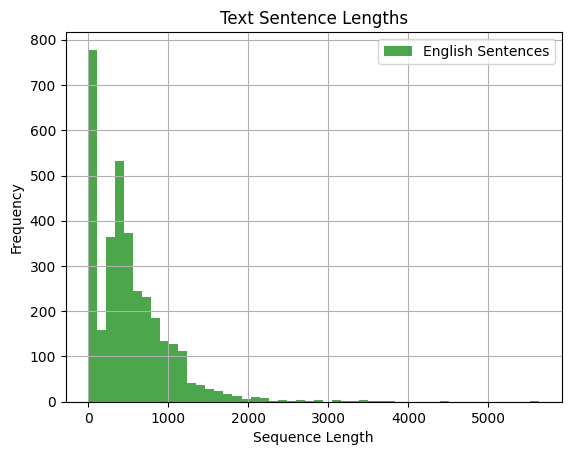

In [12]:
df.hist(column="Text_seq_length", bins=50, alpha=0.7, color='green', label='English Sentences')
plt.title('Text Sentence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

In [13]:
df[df['Text_seq_length']>1000].shape

(479, 6)

In [14]:
df = df[df['Text_seq_length']<1000]
df.shape

(2978, 6)

In [15]:
Text_sentences = df['Text'].apply(lambda x: x+' END')

In [16]:
Text_tokenizer = Tokenizer(filters='')
Text_tokenizer.fit_on_texts(Text_sentences)
num_encoder_tokens = len(Text_tokenizer.word_index) + 1

In [17]:
Text_sequences = Text_tokenizer.texts_to_sequences(Text_sentences)

In [18]:
with open('Text_tokenizer.pkl', 'wb') as f:
    pickle.dump(Text_tokenizer, f)

SetFit methods *DONE*,TO DO: make the input to take news file (i.e pdf, word, or etc), HOW TO INCREASE ACCURACY???

In [ ]:
import pandas as pd
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split

df = pd.read_csv('archive/Political_Bias.csv')

df = df.dropna(subset=['Title', 'Text', 'Bias'])
df['Bias'] = df['Bias'].str.strip().str.capitalize()
df = df[df['Bias'].isin(['Left', 'Center', 'Right'])]
df['text'] = df['Title'] + " - " + df['Text'].str[:600]
df['label'] = df['Bias']

min_class_size = df['label'].value_counts().min()
sample_size = min(min_class_size, 400) 
balanced_df = df.groupby('label').sample(n=sample_size, random_state=42)

# SetFit requirement
label_map = {
    'left': 0, 
    'lean left': 1, 
    'center': 2, 
    'lean right': 3, 
    'right': 4
}
df['label'] = df['Bias'].str.lower().map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Convert to HuggingFace Dataset format and Split
train_df, test_df = train_test_split(
    balanced_df, 
    test_size=0.2, 
    stratify=balanced_df['label'],
    random_state=42
)

full_dataset = Dataset.from_pandas(df[['text', 'label']])
dataset_split = full_dataset.train_test_split(test_size=0.2)
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

model = SetFitModel.from_pretrained(
    "sentence-transformers/all-mpnet-base-v2",
    labels=["Center", "Left", "Right"]
)

# Training Arguments (SetFit requirement)
args = TrainingArguments(
    batch_size=16,
    num_epochs=3, # Increased from 1 to 3 for deeper contrastive learning
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# Trainer (Setfit requirement)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    metric="accuracy",
    column_mapping={"text": "text", "label": "label"} 
)

print("Starting local training...")
trainer.train()

# Evaluate accuracy
metrics = trainer.evaluate()
print(f"Model Accuracy: {metrics['accuracy'] * 100:.2f}%")

model.save_pretrained("news_bias_setfit_model")

# (Testing a new article)
new_news = "The senate passed a landmark climate bill today despite heavy opposition."
probs = model.predict_proba([new_news])

# Format output
output_label = model.predict([new_news])[0].item() 
reverse_map = {v: k for k, v in label_map.items()}

confidence = probs[0][output_label].item()

print(f"Predicted Bias: {reverse_map[output_label]}")
print(f"Confidence Score: {confidence:.4f}")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
c:\Users\PC\Documents\GitHub\Political-Biases\.venv\Lib\site-packages\datasets\utils\_dill.py:379: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]
Map: 100%|██████████| 664/664 [00:00<00:00, 23713.58 examples/s]


Starting local training...


***** Running training *****
  Num unique pairs = 293930
  Batch size = 16
  Num epochs = 3
  Total optimization steps = 55113
  0%|          | 0/55113 [00:00<?, ?it/s]

                                                  

{'embedding_loss': 0.2992, 'learning_rate': 3.62844702467344e-09, 'epoch': 0.0}


{'embedding_loss': 0.337, 'learning_rate': 1.8142235123367198e-07, 'epoch': 0.0}


...

{'embedding_loss': 0.2291, 'learning_rate': 2.539912917271408e-06, 'epoch': 0.04}


{'embedding_loss': 0.2127, 'learning_rate': 2.72133526850508e-06, 'epoch': 0.04}


{'embedding_loss': 0.2147, 'learning_rate': 2.9027576197387517e-06, 'epoch': 0.04}


{'embedding_loss': 0.2038, 'learning_rate': 3.084179970972424e-06, 'epoch': 0.05}


{'embedding_loss': 0.1946, 'learning_rate': 3.265602322206096e-06, 'epoch': 0.05}


RAG Method (Retrieval Augmented Generation)

In [ ]:
import pandas as pd
from langchain_community.document_loaders import DataFrameLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import Ollama
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

df = pd.read_csv('archive/Political_Bias.csv', usecols=['Title', 'Text', 'Bias'])
# Truncate text to 500 chars for initial search - huge RAM saver
df['page_content'] = df['Title'].fillna('') + ": " + df['Text'].str[:500].fillna('')

loader = DataFrameLoader(df, page_content_column="page_content")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=20)
chunks = splitter.split_documents(docs)

# 'cpu' ensures gpu memory doesn't crash
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'} 
)

print(f"Total chunks created: {len(chunks)}")
print("Initializing empty database...")

vector_db = Chroma(
    persist_directory="./chroma_db_lite", 
    embedding_function=embeddings
)

# safely below the 5461 limit
batch_size = 5000

for i in range(0, len(chunks), batch_size):
    batch = chunks[i : i + batch_size]
    print(f"Embedding and saving batch {i} to {i + len(batch)}...")
    vector_db.add_documents(batch)

print("Vector database completely built!")

retriever = vector_db.as_retriever(search_kwargs={"k": 3})

# Use a "Small" model instead of Llama3
# Llama3 is 8B (5GB RAM); Phi3 or TinyLlama use < 2GB RAM
llm = Ollama(model="phi3") 

# PIPELINE (Modern LCEL)
template = "Context: {context}\n\nQuestion: {question}"
prompt = ChatPromptTemplate.from_template(template)

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("Lite RAG System Active. Monitoring RAM...")
print(rag_chain.invoke("Which articles discuss healthcare?"))

c:\Users\PC\Documents\GitHub\Political-Biases\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


Total chunks created: 6328
Initializing empty database...
Embedding and saving batch 0 to 5000...
Embedding and saving batch 5000 to 6328...
Vector database completely built!
Lite RAG System Active. Monitoring RAM...
1. The first article titled "More Than 300 Scientists, Physicians Sign Online Letter Supporting RFK Jr. For HHS Secretary" covers the topic of healthcare by focusing on Robert F. Kennedy Jr.'s nomination for the Department of Health and Human Services (HHS).
   > More than 300 scientists and physicians signed a letter in support...for President-elect Donald Trump’s nominee to lead the Department of Health and Human Services (HHS), environmental lawyer Robert F. Kennedy Jr. The open letter still soliciting signatures is endorsed by 331 names as of Friday morning, but it lists no organization behind the effort...
   ![_id="article_details" content="/page_content/](http://www.thefederalistmagazine.com) More Than 300 Scientists, Physicians Sign Online Letter Supporting RFK Jr.

In [ ]:
from langchain_community.llms import Ollama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Use phi3 if you need to save RAM, or llama3 for accuracy
llm = Ollama(model="phi3", temperature=0.0)

# The Strict Classification Prompt
# Explicitly forbid the LLM from chatting.
template = """You are a highly accurate political bias classification algorithm.
Analyze the following news article excerpt and determine its political bias. 

You must classify it into exactly ONE of these categories: Left, Lean Left, Center, Lean Right or Right.
Respond with ONLY the category name. Do not include any other words, punctuation, or explanations.

Article: {article}

Classification:"""

prompt = ChatPromptTemplate.from_template(template)
classifier_chain = prompt | llm | StrOutputParser()

# Testing

# Example 1: right-leaning
article_1 = "The administration's reckless government spending is driving up inflation, crippling small businesses, and hurting hardworking taxpayers."

# Example 2: left-leaning 
article_2 = "The new legislation ensures essential protections for marginalized workers while holding greedy megacorporations accountable for environmental damage."

print("Analyzing Article 1...")
pred_1 = classifier_chain.invoke({"article": article_1})
print(f"Result: {pred_1.strip()}\n")

print("Analyzing Article 2...")
pred_2 = classifier_chain.invoke({"article": article_2})
print(f"Result: {pred_2.strip()}")

Analyzing Article 1...
Result: Right

Analyzing Article 2...
Result: Left


This shit is so ass man...

Larger model? Better prompting?

Accuracy test

In [ ]:
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from langchain_community.llms import Ollama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Use llama3 for better result
def build_classifier(model_name="phi3"):
    llm = Ollama(model=model_name, temperature=0.0)
    template = """You are a strict data classification algorithm.
    Determine the political bias of the following text.
    
    Here are examples of the exact logic you must use:
    Article: "The corporate tax cuts will stimulate job growth."
    Label: Right

    Article: "The government must expand healthcare coverage for vulnerable groups."
    Label: Left

    Article: "The central bank announced a 0.5% interest rate change today."
    Label: Center
    
    Rules:
    1. You must respond with EXACTLY ONE WORD.
    2. The word MUST be one of the following: Left, Right, Center.
    3. Do not include any punctuation, explanations, or introductory text.
    
    Text: {article}
    
    Classification:"""
    prompt = ChatPromptTemplate.from_template(template)
    return prompt | llm | StrOutputParser()

def predict_bias(classifier_chain, text):
    try:
        raw_response = classifier_chain.invoke({"article": text})
        clean_label = raw_response.strip().capitalize()
        if clean_label in ["Left", "Right", "Center"]:
            return clean_label
        return "Unknown"
    except Exception as e:
        return "Error"

# Evaluation
def run_evaluation(csv_path, sample_size=50, model_name="phi3"):
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['Text', 'Bias'])
    df['Bias'] = df['Bias'].str.strip().str.capitalize()
    df = df[df['Bias'].isin(['Left', 'Right', 'Center'])]
    
    print(f"Sampling {sample_size} random articles for the test...")
    test_df = df.sample(n=sample_size, random_state=42).copy()
    
    print(f"Initializing {model_name} model...")
    classifier = build_classifier(model_name)
    
    predictions = []
    
    print("\nStarting Inference Loop:")
    for text in tqdm(test_df['Text'], desc="Classifying Articles"):
        # Truncate text to 1000 characters to keep inference fast
        short_text = str(text)[:1000] 
        pred = predict_bias(classifier, short_text)
        predictions.append(pred)
        
    test_df['Prediction'] = predictions
    valid_results = test_df[test_df['Prediction'].isin(['Left', 'Right', 'Center'])]
    failed_count = len(test_df) - len(valid_results)
    
    print("\n" + "="*50)
    print("EVALUATION RESULTS:")
    print("="*50)
    
    if failed_count > 0:
        print(f"The LLM failed to format {failed_count} responses correctly.")
    
    y_true = valid_results['Bias']
    y_pred = valid_results['Prediction']
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Center', 'Left', 'Right']))
    
    # debug
    print("\nExample Errors")
    errors = valid_results[valid_results['Bias'] != valid_results['Prediction']].head(3)
    for _, row in errors.iterrows():
        print(f"\nActual: [{row['Bias']}] | Predicted: [{row['Prediction']}]")
        print(f"Text Snippet: {str(row['Text'])[:150]}...")

if __name__ == "__main__":
    # Run the test on 50 articles.
    run_evaluation('archive/Political_Bias.csv', sample_size=50, model_name="phi3")

Loading data from archive/Political_Bias.csv...
Sampling 50 random articles for the test...
Initializing phi3 model...

Starting Inference Loop:


Classifying Articles: 100%|██████████| 50/50 [01:59<00:00,  2.38s/it]


EVALUATION RESULTS:
The LLM failed to format 8 responses correctly.

Overall Accuracy: 45.24%

Detailed Classification Report:
              precision    recall  f1-score   support

      Center       0.00      0.00      0.00         7
        Left       0.74      0.59      0.65        29
       Right       0.13      0.33      0.19         6

    accuracy                           0.45        42
   macro avg       0.29      0.31      0.28        42
weighted avg       0.53      0.45      0.48        42


Example Errors

Actual: [Center] | Predicted: [Left]
Text Snippet: A recent news story gave the anti-self-driving car pearl-clutchers some ammunition, although it was more comical than tragic. In West Hollywood last m...

Actual: [Left] | Predicted: [Right]
Text Snippet: WASHINGTON (AP) â€” Two months ago, in his first network television interview after the election, Donald Trump said he owed his victory to Americansâ€...

Actual: [Center] | Predicted: [Left]
Text Snippet: President Do